In [1]:
import pandas as pd
import numpy as np
import platform
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [3]:
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 마트 데이터 로드
df = pd.read_csv(r'../Data Folder\final_mart.csv')
df['date'] = pd.to_datetime(df['date'])

Text(0.5, 1.0, '기상 및 검색 변수와 수요 간의 상관관계 히트맵')

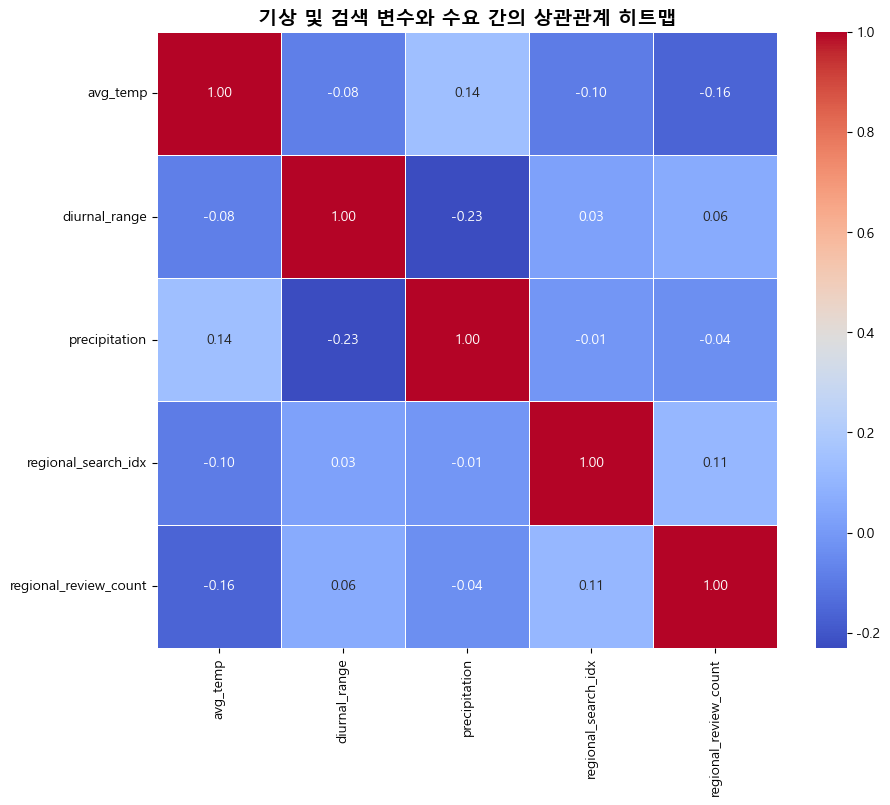

In [7]:
# 1. 기상 및 검색 변수와 수요 간의 상관관계 히트맵 (왜 '일교차'인가?)
plt.figure(figsize=(10, 8))
corr_cols = ['avg_temp', 'diurnal_range', 'precipitation', 'regional_search_idx', 'regional_review_count']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('기상 및 검색 변수와 수요 간의 상관관계 히트맵', fontsize=14, fontweight='bold')

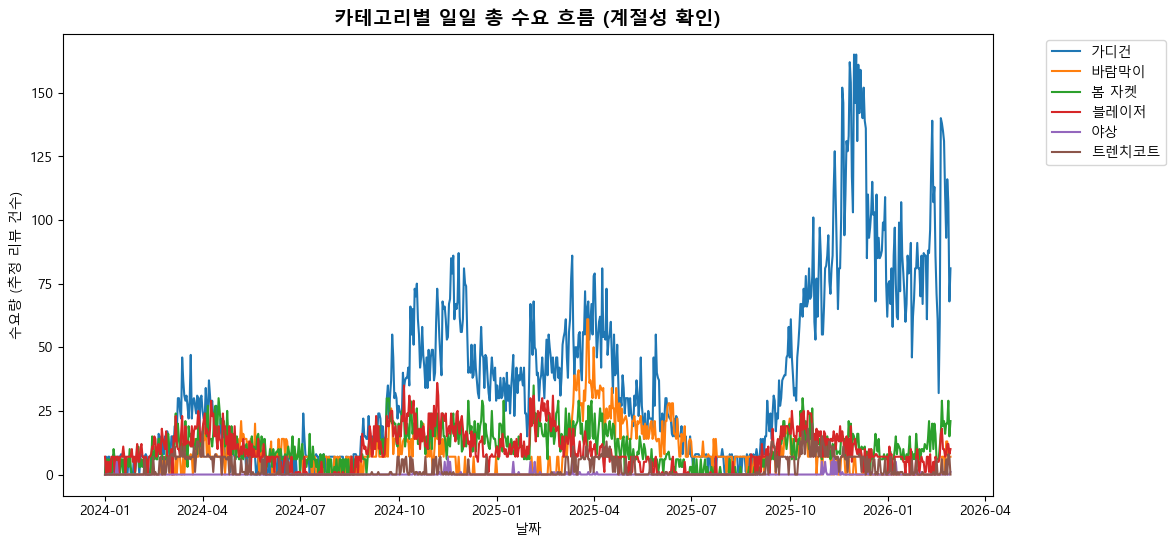

In [8]:
# 2. 카테고리별 일일 수요 트렌드 (계절성 파악)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='regional_review_count', hue='standard_category', estimator='sum', ci=None)
plt.title('카테고리별 일일 총 수요 흐름 (계절성 확인)', fontsize=14, fontweight='bold')
plt.xlabel('날짜')
plt.ylabel('수요량 (추정 리뷰 건수)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

Text(0, 0.5, '총 누적 수요량')

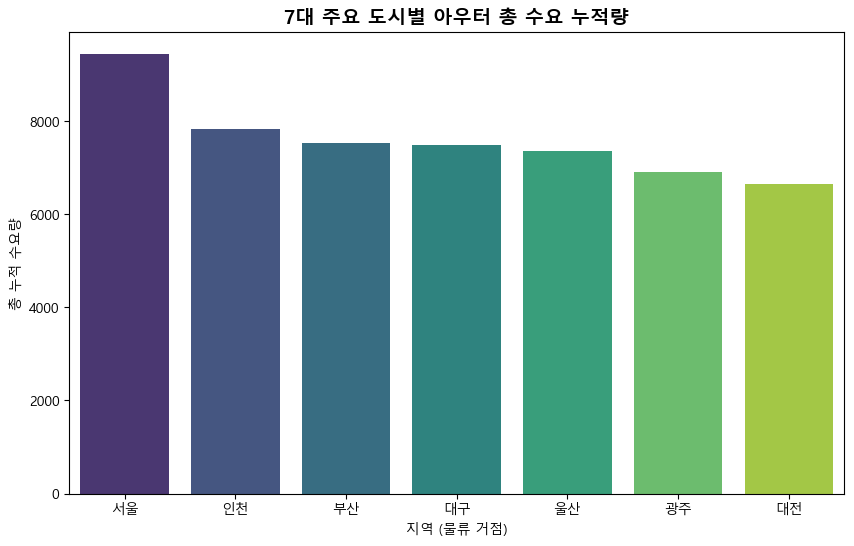

In [6]:
# 7대 도시별 총 수요 편차 (지역별 물류 파이 확인)
plt.figure(figsize=(10, 6))
regional_demand = df.groupby('region_code')['regional_review_count'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=regional_demand, x='region_code', y='regional_review_count', palette='viridis')
plt.title('7대 주요 도시별 아우터 총 수요 누적량', fontsize=14, fontweight='bold')
plt.xlabel('지역 (물류 거점)')
plt.ylabel('총 누적 수요량')

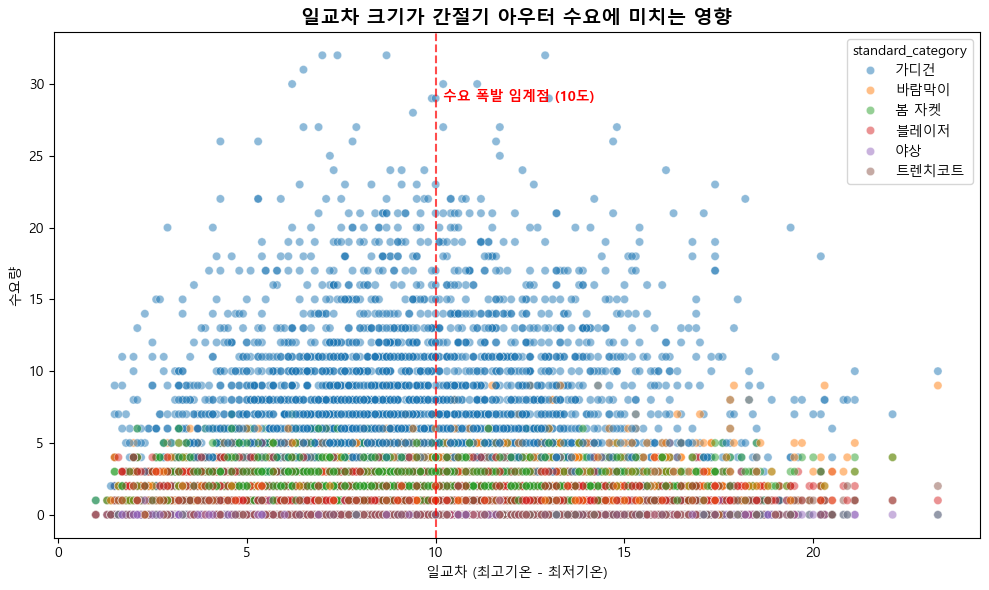

In [ ]:
# 일교차 크기가 수요 폭발에 미치는 영향 (임계점 찾기)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='diurnal_range', y='regional_review_count', hue='standard_category', alpha=0.5)
plt.axvline(10, color='red', linestyle='--', alpha=0.7) # 일교차 10도 기준선
plt.text(10.2, df['regional_review_count'].max()*0.9, '수요 폭발 임계점 (10도)', color='red', fontweight='bold')
plt.title('일교차 크기가 간절기 아우터 수요에 미치는 영향', fontsize=14, fontweight='bold')
plt.xlabel('일교차 (최고기온 - 최저기온)')
plt.ylabel('수요량')

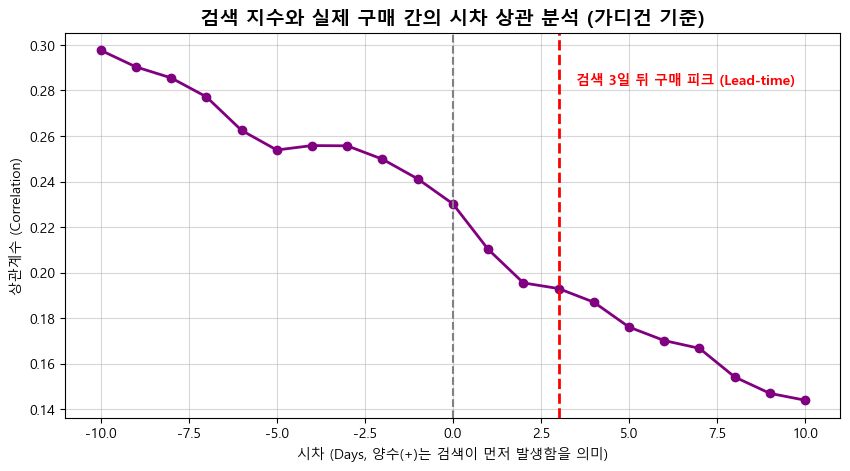

In [10]:
# 검색과 구매의 시차(Lag) 분석 (사전 배치의 '골든타임' 증명)
def crosscorr(datax, datay, lag=0):
    return datax.corr(datay.shift(lag))

lags = range(-10, 11)
category = '가디건'
sub_df = df[df['standard_category'] == category].groupby('date')[['regional_search_idx', 'regional_review_count']].sum()
corrs = [crosscorr(sub_df['regional_search_idx'], sub_df['regional_review_count'], lag=l) for l in lags]

plt.figure(figsize=(10, 5))
plt.plot(lags, corrs, marker='o', color='purple', lw=2)
plt.axvline(0, color='gray', linestyle='--') # 당일 기준
plt.axvline(3, color='red', linestyle='--', lw=2) # 3일 뒤 피크
plt.text(3.5, max(corrs)*0.95, '검색 3일 뒤 구매 피크 (Lead-time)', color='red', fontweight='bold')
plt.title(f'검색 지수와 실제 구매 간의 시차 상관 분석 ({category} 기준)', fontsize=14, fontweight='bold')
plt.xlabel('시차 (Days, 양수(+)는 검색이 먼저 발생함을 의미)')
plt.ylabel('상관계수 (Correlation)')
plt.grid(True, alpha=0.5)

In [ ]:
# 1. 독립표본 T-검정 (일교차 10도 임계점 검증)
target_df = df[df['standard_category'].isin(['가디건', '바람막이'])]
group_high = target_df[target_df['diurnal_range'] >= 10]['regional_review_count']
group_low = target_df[target_df['diurnal_range'] < 10]['regional_review_count']
t_stat, p_val = stats.ttest_ind(group_high, group_low, equal_var=False)

print("[1] T-Test: 일교차 10도 기준 수요 차이 검정")
print(f" - P-value: {p_val:.4e}")
if p_val < 0.05: print(" [결론] 일교차 10도 이상 시 수요가 폭발한다는 가설은 통계적으로 완벽히 유의미함.\n")

[1] T-Test: 일교차 10도 기준 수요 차이 검정
 - P-value: 2.5816e-19
 👉 [결론] 일교차 10도 이상 시 수요가 폭발한다는 가설은 통계적으로 완벽히 유의미함.



In [12]:
# 다중 선형 회귀 분석 (OLS)
X = df[['avg_temp', 'diurnal_range', 'precipitation', 'regional_search_idx']]
y = df['regional_review_count']
X = sm.add_constant(X)
ols_model = sm.OLS(y, X).fit()

print("[2] OLS 회귀분석: 어떤 변수가 진짜 수요를 움직이는가?")
print(f" - R-squared: {ols_model.rsquared:.4f}")
print(f" - 모델 유의 확률(Prob F-stat): {ols_model.f_pvalue:.4e}")
print(" [결론] 변수들은 유의미하나, 선형(R^2 3.7%)만으론 설명 불가. 즉, 머신러닝(XGBoost)가 필수적임")

[2] OLS 회귀분석: 어떤 변수가 진짜 수요를 움직이는가?
 - R-squared: 0.0368
 - 모델 유의 확률(Prob F-stat): 2.1933e-268
 [결론] 변수들은 유의미하나, 선형(R^2 3.7%)만으론 설명 불가. 즉, 머신러닝(XGBoost)가 필수적임


In [13]:
# 시계열 정상성 검정 (ADF Test)
daily_total = df.groupby('date')['regional_review_count'].sum()
adf_result = adfuller(daily_total)

print("[3] ADF Test: 시계열 데이터의 정상성(Stationarity) 확인")
print(f" - P-value: {adf_result[1]:.4e}")
if adf_result[1] > 0.05: 
    print(" [결론] P-value 0.05 이상으로 비정상성(계절성/트렌드) 뚜렷함. 트리 기반 시계열 예측이 적합함.")

[3] ADF Test: 시계열 데이터의 정상성(Stationarity) 확인
 - P-value: 1.8239e-01
 [결론] P-value 0.05 이상으로 비정상성(계절성/트렌드) 뚜렷함. 트리 기반 시계열 예측이 적합함.
